In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\sumit\DATA_SCIENCE\CodeAlpha INTERNSHIP\Task2\Advertising.csv")

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
print('Missing values in each column:')
display(df.isnull().sum())

print('\nDescriptive statistics of the DataFrame:')
display(df.describe())

Missing values in each column:


Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


Descriptive statistics of the DataFrame:


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


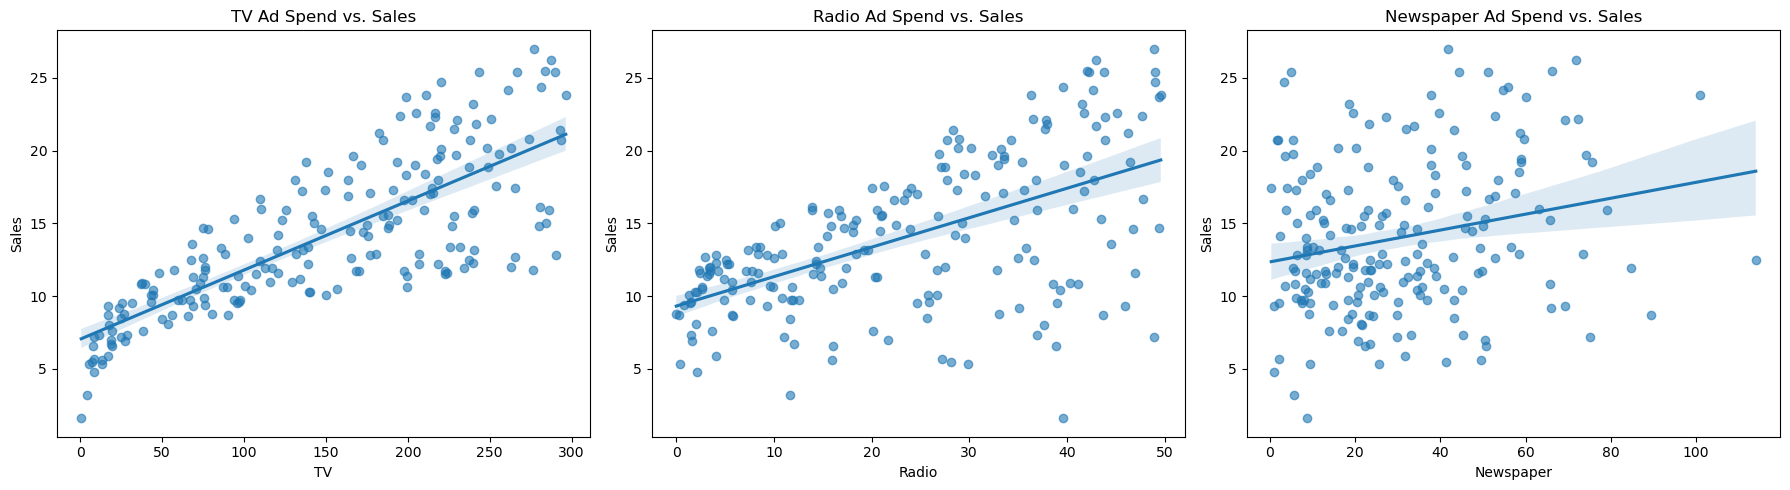

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the 'Unnamed: 0' column as it appears to be an index column
df = df.drop('Unnamed: 0', axis=1)

# Visualize the relationships between features and sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.regplot(x='TV', y='Sales', data=df, ax=axes[0], scatter_kws={'alpha':0.6})
sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1], scatter_kws={'alpha':0.6})
sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2], scatter_kws={'alpha':0.6})

axes[0].set_title('TV Ad Spend vs. Sales')
axes[1].set_title('Radio Ad Spend vs. Sales')
axes[2].set_title('Newspaper Ad Spend vs. Sales')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients)
print(f"Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 3.17
R-squared (R2): 0.90


,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


Intercept: 2.98


In [5]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier viewing and maintain column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('Scaled training data (first 5 rows):')
display(X_train_scaled_df.head())

print('\nScaled test data (first 5 rows):')
display(X_test_scaled_df.head())

Scaled training data (first 5 rows):


,TV,Radio,Newspaper
0,-0.404248,-1.028237,-0.337675
1,0.320608,-0.919828,-1.161439
2,-1.270511,0.259124,0.254251
3,-1.042359,-0.696233,-0.574446
4,0.879103,-1.387343,-0.707629



Scaled test data (first 5 rows):


,TV,Radio,Newspaper
0,0.157812,0.591127,1.132275
1,0.539253,1.681996,1.132275
2,1.697834,0.367533,0.653801
3,-1.643633,0.950233,0.752455
4,0.835137,1.770079,-1.319286


In [6]:
# Initialize and train the Linear Regression model with scaled data
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = scaled_model.predict(X_test_scaled)

# Evaluate the model
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Mean Squared Error (MSE) with scaled features: {mse_scaled:.2f}")
print(f"R-squared (R2) with scaled features: {r2_scaled:.2f}")

# Display model coefficients for scaled features
coefficients_scaled = pd.DataFrame({'Feature': X.columns, 'Coefficient': scaled_model.coef_})
display(coefficients_scaled)
print(f"Intercept with scaled features: {scaled_model.intercept_:.2f}")

Mean Squared Error (MSE) with scaled features: 3.17
R-squared (R2) with scaled features: 0.90


,Feature,Coefficient
0,TV,3.764196
1,Radio,2.792307
2,Newspaper,0.055976


Intercept with scaled features: 14.10


In [7]:
import numpy as np

# Define hypothetical new advertising spend values
# Example: If we spend $250k on TV, $30k on Radio, and $40k on Newspaper
new_ad_spend = pd.DataFrame([{'TV': 250, 'Radio': 30, 'Newspaper': 40}])
display(new_ad_spend)

# Scale the new advertising spend using the previously fitted scaler
new_ad_spend_scaled = scaler.transform(new_ad_spend)

# Predict sales using the scaled model
predicted_sales = scaled_model.predict(new_ad_spend_scaled)

print(f"\nPredicted Sales for the hypothetical spend: {predicted_sales[0]:.2f} units")

,TV,Radio,Newspaper
0,250,30,40



Predicted Sales for the hypothetical spend: 19.95 units


In [8]:
def predict_sales(tv_spend, radio_spend, newspaper_spend, model, scaler):
    """Predicts sales for given advertising spend using the trained scaled model.

    Args:
        tv_spend (float): Spend on TV advertising.
        radio_spend (float): Spend on Radio advertising.
        newspaper_spend (float): Spend on Newspaper advertising.
        model (sklearn.linear_model.LinearRegression): The trained linear regression model.
        scaler (sklearn.preprocessing.StandardScaler): The fitted StandardScaler.

    Returns:
        float: Predicted sales units.
    """
    new_data = pd.DataFrame([{'TV': tv_spend, 'Radio': radio_spend, 'Newspaper': newspaper_spend}])
    new_data_scaled = scaler.transform(new_data)
    predicted_sales = model.predict(new_data_scaled)
    return predicted_sales[0]

# Example: Predict sales with some baseline values
baseline_tv = 150
baseline_radio = 20
baseline_newspaper = 15
baseline_sales = predict_sales(baseline_tv, baseline_radio, baseline_newspaper, scaled_model, scaler)

print(f"Baseline predicted sales: {baseline_sales:.2f} units for TV={baseline_tv}, Radio={baseline_radio}, Newspaper={baseline_newspaper}")

Baseline predicted sales: 13.51 units for TV=150, Radio=20, Newspaper=15


,TV_Spend,Predicted_Sales
0,50.000000,9.040861
1,77.777778,10.283348
2,105.555556,11.525834
3,133.333333,12.768321
4,161.111111,14.010807


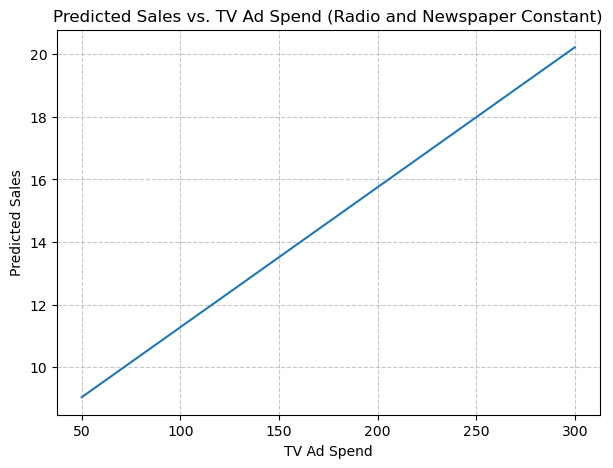

In [14]:
tv_spends = np.linspace(50, 300, 10)
predicted_sales_tv_varies = []

for tv in tv_spends:
    sales = predict_sales(tv, baseline_radio, baseline_newspaper, scaled_model, scaler)
    predicted_sales_tv_varies.append(sales)

# Create a DataFrame for plotting
tv_impact_df = pd.DataFrame({
    'TV_Spend': tv_spends,
    'Predicted_Sales': predicted_sales_tv_varies
})

display(tv_impact_df.head())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.lineplot(x='TV_Spend', y='Predicted_Sales', data=tv_impact_df)
plt.title('Predicted Sales vs. TV Ad Spend (Radio and Newspaper Constant)')
plt.xlabel('TV Ad Spend')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


,Radio_Spend,Predicted_Sales
0,0.000000,9.729912
1,5.555556,10.780995
2,11.111111,11.832079
3,16.666667,12.883163
4,22.222222,13.934246


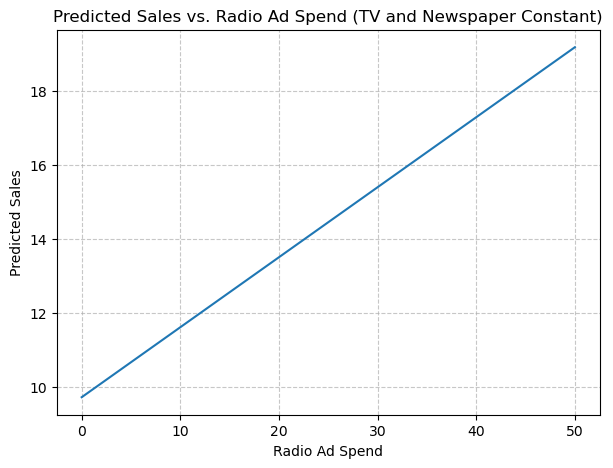

In [12]:
# Analyze impact of Radio ad spend
radio_spends = np.linspace(0, 50, 10) # Radio spend typically ranges from 0 to 50
predicted_sales_radio_varies = []

for radio in radio_spends:
    sales = predict_sales(baseline_tv, radio, baseline_newspaper, scaled_model, scaler)
    predicted_sales_radio_varies.append(sales)

# Create a DataFrame for plotting
radio_impact_df = pd.DataFrame({
    'Radio_Spend': radio_spends,
    'Predicted_Sales': predicted_sales_radio_varies
})

display(radio_impact_df.head())

plt.figure(figsize=(7, 5))
sns.lineplot(x='Radio_Spend', y='Predicted_Sales', data=radio_impact_df)
plt.title('Predicted Sales vs. Radio Ad Spend (TV and Newspaper Constant)')
plt.xlabel('Radio Ad Spend')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

,Newspaper_Spend,Predicted_Sales
0,0.000000,13.472396
1,11.111111,13.503075
2,22.222222,13.533754
3,33.333333,13.564433
4,44.444444,13.595112


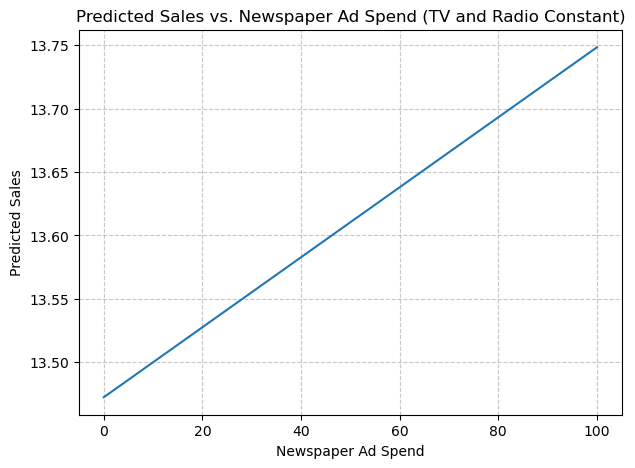

In [13]:
# Analyze impact of Newspaper ad spend
newspaper_spends = np.linspace(0, 100, 10) # Newspaper spend typically ranges from 0 to 100
predicted_sales_newspaper_varies = []

for newspaper in newspaper_spends:
    sales = predict_sales(baseline_tv, baseline_radio, newspaper, scaled_model, scaler)
    predicted_sales_newspaper_varies.append(sales)

# Create a DataFrame for plotting
newspaper_impact_df = pd.DataFrame({
    'Newspaper_Spend': newspaper_spends,
    'Predicted_Sales': predicted_sales_newspaper_varies
})

display(newspaper_impact_df.head())

plt.figure(figsize=(7, 5))
sns.lineplot(x='Newspaper_Spend', y='Predicted_Sales', data=newspaper_impact_df)
plt.title('Predicted Sales vs. Newspaper Ad Spend (TV and Radio Constant)')
plt.xlabel('Newspaper Ad Spend')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()